<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Processamento_de_Imagem_Mecha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#Importar Bibliotecas
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files, drive
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image
import matplotlib.pyplot as plt
import os

In [16]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Função para carregar imagens
def carregar_imagens():
    uploaded = files.upload()  # Permite ao usuário fazer upload de imagens
    imagens = []
    nomes = []
    for nome_arquivo in uploaded.keys():
        img = cv2.imread(nome_arquivo)
        if img is not None:
            imagens.append(img)
            nomes.append(nome_arquivo)
    return imagens, nomes

In [18]:
# Carregar imagens
imagens, nomes = carregar_imagens()

Saving 12.JPG to 12 (2).JPG
Saving 13.JPG to 13 (2).JPG
Saving 14.JPG to 14 (2).JPG


In [76]:
# Função para exibir imagens em uma grade
def exibir_imagens_em_grade(imagens, titulos=None, max_colunas=4):
    num_imagens = len(imagens)
    num_linhas = (num_imagens + max_colunas - 1) // max_colunas  # Calcula o número de linhas necessário

    plt.figure(figsize=(15, 5 * num_linhas))  # Ajusta o tamanho da figura com base no número de linhas

    for i, img in enumerate(imagens):
        plt.subplot(num_linhas, max_colunas, i + 1)  # Cria subplots
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converte BGR para RGB para exibição
        if titulos:
            plt.title(titulos[i])  # Adiciona o título
        plt.axis('off')  # Remove os eixos

    plt.tight_layout()  # Ajusta o layout para evitar sobreposição
    plt.show()

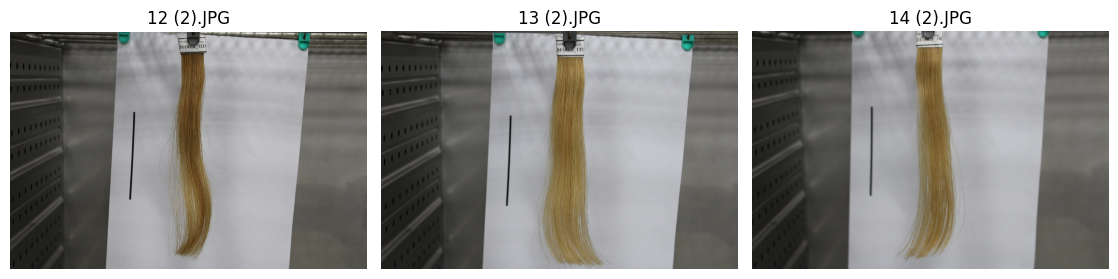

In [77]:
exibir_imagens_em_grade(imagens, nomes)

In [82]:
# Função para detectar a mecha de cabelo e calcular a área
def detectar_mecha_e_calcular_area(imagem):
    # Converter para o espaço de cores HSV
    hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

    # Definir intervalo de cores para a mecha de cabelo (amarelo)
    lower_yellow = np.array([20, 50, 50])  # Limite inferior (ajustar se necessário)
    upper_yellow = np.array([40, 255, 255])  # Limite superior (ajustar se necessário)

    # Definir intervalo de cores para a mecha de cabelo (castanho)
    lower_brown = np.array([10, 20, 20])  # Limite inferior para castanho
    upper_brown = np.array([20, 200, 200])  # Limite superior para castanho

    # Criar máscaras para amarelo e castanho
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_brown = cv2.inRange(hsv, lower_brown, upper_brown)

      # Combinar as máscaras (amarelo + castanho)
    mask = cv2.bitwise_or(mask_yellow, mask_brown)

    # Aplicar operações morfológicas para limpar a máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Encontrar contornos na máscara combinada
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Verificar se há contornos detectados
    if len(contours) == 0:
        print("Nenhum contorno encontrado!")
        return imagem, None, 0, 0

    # Selecionar o maior contorno (assumindo que a mecha de cabelo é a maior região detectada)
    maior_contorno = max(contours, key=cv2.contourArea)

    # Calcular a área do maior contorno
    area_mecha = cv2.contourArea(maior_contorno)

    # Criar uma cópia da imagem original para desenhar o contorno
    imagem_com_contorno = imagem.copy()
    cv2.drawContours(imagem_com_contorno, [maior_contorno], -1, (0, 255, 0), 2)  # Verde para o contorno

    # Detectar a linha preta para calcular a área relativa
    lower_black = np.array([0, 0, 0])  # Limite inferior para preto
    upper_black = np.array([180, 255, 50])  # Limite superior para preto
    mask_black = cv2.inRange(hsv, lower_black, upper_black)

    # Encontrar contornos da linha preta
    contours_black, _ = cv2.findContours(mask_black, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Verificar se há contornos para a linha preta
    if len(contours_black) == 0:
        print("Linha preta não encontrada!")
        return imagem_com_contorno, maior_contorno, area_mecha, 0

    # Selecionar o maior contorno da linha preta (assumindo que é a linha de referência)
    linha_preta = max(contours_black, key=cv2.contourArea)
    area_linha_preta = cv2.contourArea(linha_preta)

    # Calcular a área relativa da mecha em relação à linha preta
    area_relativa = area_mecha / area_linha_preta if area_linha_preta > 0 else 0

    return imagem_com_contorno, maior_contorno, area_mecha, area_relativa

In [85]:
# Função para exibir a área interna definida pelo contorno
def exibir_area_interna(imagem, contorno):
    # Criar uma máscara para o contorno
    mask = np.zeros(imagem.shape[:2], dtype=np.uint8)
    cv2.drawContours(mask, [contorno], -1, 255, thickness=cv2.FILLED)

    # Aplicar a máscara na imagem original
    area_interna = cv2.bitwise_and(imagem, imagem, mask=mask)

    # Recortar a região delimitada pelo contorno
    x, y, w, h = cv2.boundingRect(contorno)
    return area_interna[y:y+h, x:x+w]

IndexError: list index out of range

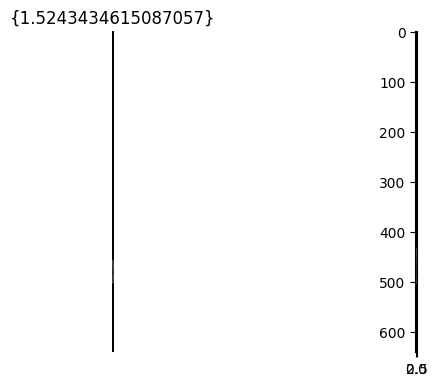

In [91]:
# Processar cada imagem
imagens_com_contorno = []
titulos = []
for i, img in enumerate(imagens):
    # Detectar a mecha e calcular a área
    imagem_com_contorno, contorno, area_mecha, area_relativa = detectar_mecha_e_calcular_area(img)

    # Adicionar a imagem processada à lista
    imagens_com_contorno.append(imagem_com_contorno)
    titulos.append(f"{nomes[i]}\nÁrea: {area_mecha:.2f}\nRelativa: {area_relativa:.2f}")

    # Exibir informações no console
#    print(f"Processado: {nomes[i]}")
#    print(f"Área da mecha: {area_mecha:.2f} pixels")
#    print(f"Área relativa (em relação à linha preta): {area_relativa:.2f}")

    exibir_imagens_em_grade(exibir_area_interna(img, contorno), titulos=[{area_relativa}])


In [ ]:
# Exibir todas as imagens processadas em uma grade
exibir_imagens_em_grade(imagens_com_contorno, titulos=titulos)